In [1]:
# need to restart jupyter server? kernal? whenever a change is made to the pybamm module? 
import sys
import os
import numpy as np
import pandas as pd
import os
from scipy import integrate
import matplotlib.colors
import matplotlib.pyplot as plt
from pylab import gca
from mpl_toolkits.axes_grid1 import make_axes_locatable
sys.path.insert(0, r'c:\Users\Vivian\Dropbox (University of Michigan)\from_box\Research\PyBaMM\PyBaMM')
print(sys.path[0])
import pybamm
print(pybamm.__path__[0])
%matplotlib widget
# inline
import inspect
plt.rcParams.update({
    'text.usetex': True,
    'font.family': 'serif',
    'font.serif': 'Computer Modern',
    'font.sans-serif': ['Computer Modern'],
    'font.size': 9,
})


c:\Users\Vivian\Dropbox (University of Michigan)\from_box\Research\PyBaMM\PyBaMM
c:\Users\Vivian\Dropbox (University of Michigan)\from_box\Research\PyBaMM\PyBaMM\pybamm


In [2]:
# class ExternalCircuitResistanceFunction():
#     def __call__(self, variables):
#         I = variables["Current [A]"]
#         V = variables["Terminal voltage [V]"]
#         R_ext = pybamm.FunctionParameter("External resistance [Ohm]",  {"Time [s]": pybamm.t}) 
#         R_tab = pybamm.FunctionParameter("Tabbing resistance [Ohm]",  {"Time [s]": pybamm.t})
#         return V/I - (R_ext + R_tab)

# Set up concentration dependent functions

In [3]:
from pybamm import exp, constants, Parameter


def modified_graphite_diffusivity_PeymanMPM(sto, T):
    D_ref =  8e-14 #Parameter("Negative electrode diffusion coefficient [m2.s-1]")
    # D_ref = 16*5.0 * 10 ** (-15)
    E_D_s = 42770/10
    arrhenius = exp(E_D_s / constants.R * (1 / 298.15 - 1 / T))

    soc = (sto - 0)/(0.8321-0)
    k = 1.12070451*soc + 0.09209274 # Ds_restart_rmseV_11_simultaneous_rest (updated exp C-rate) only exclude kn>9
    # k = pybamm.maximum(k, 0.1)
    return D_ref*k # *(-0.9 * sto + 1)

def modified_NMC_diffusivity_PeymanMPM(sto, T):
    D_ref =  8e-15 #Parameter("Positive electrode diffusion coefficient [m2.s-1]")
    E_D_s = 18550/10
    soc = (0.837-sto)/(0.837-0.034)
    k =  4.7302281*soc**2  -4.5023245*soc + 1.26466141 # # Ds_restart_rmseV_11_simultaneous_rest (updated exp C-rate)
    return D_ref *k

def modified_electrolyte_diffusivity_PeymanMPM(c_e, T):
    # D_c_e = 5.35 * 10 ** (-10)
    D_c_e =  Parameter("Typical electrolyte diffusivity [m2.s-1]")
    E_D_e = 37040
    arrhenius = exp(E_D_e / constants.R * (1 / 298.15 - 1 / T))
    return D_c_e#*arrhenius

def modified_electrolyte_conductivity_PeymanMPM(c_e, T):
    # sigma_e = 1.3
    sigma_e = Parameter("Typical electrolyte conductivity [m2.s-1]")
    E_k_e = 34700
    arrhenius = exp(E_k_e / constants.R * (1 / 298.15 - 1 / T))
    return sigma_e#*k_T# (1-k)#*arrhenius

def modified_NMC_electrolyte_exchange_current_density_PeymanMPM(c_e, c_s_surf, c_s_max, T):
    m_ref =  Parameter("Positive electrode reference exchange-current density [A.m-2(m3.mol)1.5]")
    E_r = 39570
    arrhenius = exp(E_r / constants.R * (1 / 298.15 - 1 / T))

    return (
        m_ref * c_e**0.5 * c_s_surf**0.5 * (c_s_max - c_s_surf) ** 0.5
    )

def modified_graphite_electrolyte_exchange_current_density_PeymanMPM(c_e, c_s_surf, c_s_max, T):
    m_ref =  Parameter("Negative electrode reference exchange-current density [A.m-2(m3.mol)1.5]")
    E_r = 37480
    arrhenius = exp(E_r / constants.R * (1 / 298.15 - 1 / T))

    return (
        m_ref * c_e**0.5 * c_s_surf**0.5 * (c_s_max - c_s_surf) ** 0.5
    )

# Simulate 100% SOC ESC

## Nominal model

In [54]:
solutions = []
SOC_0 = 1
SOC_name = SOC_0
Q_nom = 4.6
h = 34.83874617168782 
k_Cp = 2.4847642158614396
R_tab = pybamm.Parameter("Tabbing resistance [Ohm]")
R_ext = pybamm.Parameter("External resistance [Ohm]")

options = {
    # "SEI": "constant",
    "thermal": "lumped",
    "decomposition": "true", 
    "venting":"true",
    # "operating mode": ExternalCircuitResistanceFunction(),
}

model = pybamm.lithium_ion.SPMe(options = options)
chemistry = pybamm.parameter_sets.Tran2023
param = pybamm.ParameterValues(chemistry)
T_amb = 23
param.update({
    # "Tabbing resistance [Ohm]":  0.000,#0.0041,D
    # "External resistance [Ohm]": 0.0067, # 0.0067
    # "Resistance function [Ohm]": 0.0086+0.0067,
    "Cell capacity [A.h]": Q_nom, #nominal
    "Typical current [A]": Q_nom,
    'Nominal cell capacity [A.h]': Q_nom,
    "Negative electrode thickness [m]":62E-06*4.2/5,
    "Positive electrode thickness [m]":67E-06*4.2/5,
    "Lower voltage cut-off [V]": 0,
    "Ambient temperature [K]":T_amb + 273.15,
    "Initial temperature [K]": T_amb + 273.15,
    "Negative tab width [m]":2.5e-2,
    "Positive tab width [m]":2.5e-2,
    "Total heat transfer coefficient [W.m-2.K-1]":h,
    "Negative electrode specific heat capacity [J.kg-1.K-1]": 1100*k_Cp,
    "Positive electrode specific heat capacity [J.kg-1.K-1]": 1100*k_Cp,
    "Negative electrode diffusivity [m2.s-1]": modified_graphite_diffusivity_PeymanMPM,
    "Positive electrode diffusivity [m2.s-1]": modified_NMC_diffusivity_PeymanMPM,
    "Electrolyte diffusivity [m2.s-1]": modified_electrolyte_diffusivity_PeymanMPM,
    "Electrolyte conductivity [S.m-1]": modified_electrolyte_conductivity_PeymanMPM,
    # "Initial concentration in electrolyte [mol.m-3]":1000, #*1.3
    "Negative electrode exchange-current density [A.m-2]": modified_graphite_electrolyte_exchange_current_density_PeymanMPM,
    "Positive electrode exchange-current density [A.m-2]": modified_NMC_electrolyte_exchange_current_density_PeymanMPM,
    "Negative electrode OCP entropic change [V.K-1]":0,
    "Positive electrode OCP entropic change [V.K-1]":0,
    "Frequency factor for SEI decomposition [s-1]": 1.67E15*0.13210066,
    # "SEI resistivity [Ohm.m]": 1000000.0,
}, check_already_exists = False)

V = model.variables["Terminal voltage [V]"]
I = model.variables["Current [A]"]
model.variables.update({
    "Measured voltage [V]": V - I*R_tab,
    # "Actual resistance [Ohm]":V/I,
    }
)

# experiment = pybamm.Experiment(
#     [   
#         # "Discharge at C/3 until 3.0 V",
#         # "Rest for 1 hour",
#         # "Charge at C/3 until 4.2 V",
#         # "Hold at 4.2 V until C/100",
#         # "Rest for 1 hour",
#         "Discharge at 0.0067 Ohm for 15 minutes",
#         # "Rest for 1 hour",
#     ], period = "1 second",
#     )

experiment = pybamm.Experiment(
    [   
        "Rest for 1 minute",
        "Discharge at 1C for 10 minutes",
        "Rest for 10 minutes",
        "Discharge at 3C for 10 seconds",
        "Rest for 10 minutes",
        "Charge at C/3 until 4.2 V",
        "Hold at 4.2 V until C/50",
        "Rest for 1 hour",
        "Discharge at C/20 until 3.0 V",
        "Rest for 1 hour",
    ], period = "1 second",
    )

dt = 0.1
t_end = 3600*8.5
t_eval = np.arange(0, t_end, dt)


solver = pybamm.CasadiSolver(mode="safe", dt_max=1e-10,) #, extra_options_setup={"max_num_steps": 10000}
sim = pybamm.Simulation(model, parameter_values = param, solver=solver, experiment=experiment) #var_pts=var_pts
solution = sim.solve(initial_soc=1) #, t_eval = t_eval 


## FIG: Plot results

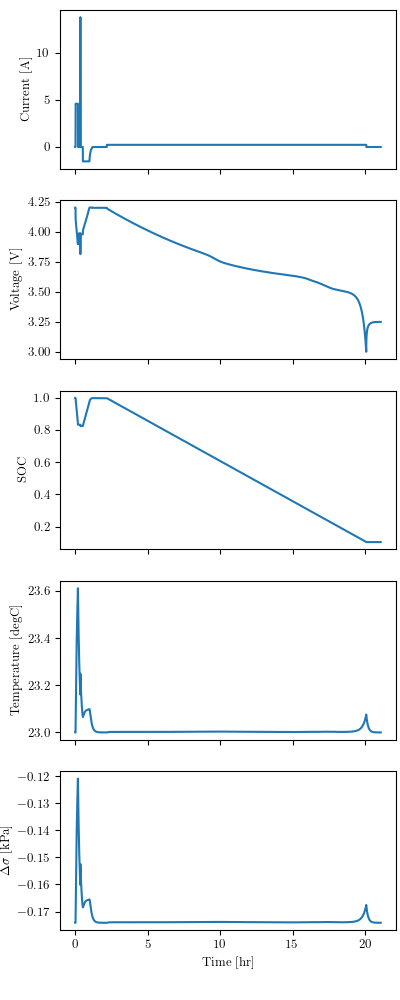

In [56]:
sol=solution
t = sol['Time [s]'].entries #np.linspace(0,3600*7,60*7)
# t_norm = np.linspace(0,3600*4,60*4)
I = sol['Current [A]']
# I = solution['C-rate']
V = sol['Terminal voltage [V]']
# V_meas = sol['Measured voltage [V]']
T = sol['Volume-averaged cell temperature [K]']
x_sei = sol['Fraction of Li in SEI']
x = solution["x [m]"].entries[:, 0]
delta_sigma = sol["Cell expansion stress [kPa]"]

fig, ax = plt.subplots(5,1, figsize=(4,10), sharex=True) #
plt.subplots_adjust(left=0.15, bottom=0.07, right=0.99, top=0.99)
# ax = ax.flatten()    
ax[0].plot(t/3600, I(t))
# ax[0].set_xlabel('Time [hr]')
# ax[0].set_ylabel('C-rate [A/Ah]')
ax[0].set_ylabel('Current [A]')
# ax[0].legend(loc = "lower left",  prop={'size': 10})
# ax[0].set_ylim([0,51])

ax[1].plot(t/3600, V(t), label = 'Terminal voltage')
# ax[1].plot(t/3600, V_meas(t),label = 'Measured voltage')
# ax[1].set_xlabel('Time [hr]')
ax[1].set_ylabel('Voltage [V]')
# ax[1].legend()

soc = SOC_0 - integrate.cumtrapz(I(t),t)/3600/Q_nom
soc = np.insert(soc,0,SOC_0)
ax[2].plot(t/3600, soc)  # can evaluate at arbitrary x (single representative particle)
# ax[2].set_xlabel('Time [hr]')
ax[2].set_ylabel('SOC')

ax[3].plot(t/3600, T(t)-273.15)
# ax[3].set_xlabel('Time [hr]')
ax[3].set_ylabel('Temperature [degC]')

ax[4].plot(t/3600, delta_sigma(t))
ax[4].set_xlabel('Time [hr]')
ax[4].set_ylabel('$\Delta\sigma$ [kPa]')

sim_results = pd.DataFrame.from_dict({'t':t, 'I':I(t=t), 'V_t':V(t=t), "T":T(t=t), 'x_sei':x_sei(t=t), 'soc':soc}) #'V_measured':V_meas(t=t),
sim_results.to_csv(r'C:\Users\Vivian\University of Michigan Dropbox\Vivian Tran\from_box\Research\PyBaMM\PyBaMM\pybamm_simulink\model_validation\pybamm_ESC_sim_results\pybamm_100A_pulse_C20.csv')
plt.savefig(r'C:\Users\Vivian\University of Michigan Dropbox\Vivian Tran\from_box\Research\PyBaMM\PyBaMM\pybamm_simulink\model_validation\pybamm_ESC_sim_results\pybamm_100A_pulse_C20.jpg', dpi = 300,) #, pad_inches=0.2  bbox_inches='tight'



# References

The relevant papers for this notebook are:

In [ ]:
pybamm.print_citations()

[1] Weilong Ai, Ludwig Kraft, Johannes Sturm, Andreas Jossen, and Billy Wu. Electrochemical thermal-mechanical modelling of stress inhomogeneity in lithium-ion pouch cells. Journal of The Electrochemical Society, 167(1):013512, 2019. doi:10.1149/2.0122001JES.
[2] Joel A. E. Andersson, Joris Gillis, Greg Horn, James B. Rawlings, and Moritz Diehl. CasADi – A software framework for nonlinear optimization and optimal control. Mathematical Programming Computation, 11(1):1–36, 2019. doi:10.1007/s12532-018-0139-4.
[3] Rutooj Deshpande, Mark Verbrugge, Yang-Tse Cheng, John Wang, and Ping Liu. Battery cycle life prediction with coupled chemical degradation and fatigue mechanics. Journal of the Electrochemical Society, 159(10):A1730, 2012. doi:10.1149/2.049210jes.
[4] Charles R. Harris, K. Jarrod Millman, Stéfan J. van der Walt, Ralf Gommers, Pauli Virtanen, David Cournapeau, Eric Wieser, Julian Taylor, Sebastian Berg, Nathaniel J. Smith, and others. Array programming with NumPy. Nature, 585(782